In [12]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [14]:
from langchain_openai import ChatOpenAI

In [15]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

### both the subGraph and Graph will share the same state

In [16]:
class graphState(TypedDict):
    question : str
    answer : str
    translated_answer : str

In [17]:
def Translate(state:graphState):
    prompt = f"convert this english text {state['answer']} into the nepali text\n keep it natural and human spoken as same as that of english."
    response = llm.invoke(prompt).content
    return {'translated_answer':response}

In [18]:
subGraphBuilder = StateGraph(state_schema=graphState)
subGraphBuilder.add_node('Translate',Translate)

subGraphBuilder.add_edge(START,'Translate')


subGraph = subGraphBuilder.compile()

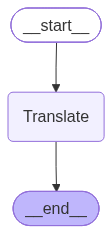

In [19]:
subGraph

In [20]:
def Generate(state:graphState):
    response = llm.invoke(state['question']).content
    return {'answer':response}

In [21]:
graphBuilder = StateGraph(state_schema=graphState)

graphBuilder.add_node('Generate',Generate)
graphBuilder.add_node('Translate_answer',subGraph)

graphBuilder.add_edge(START,'Generate')
graphBuilder.add_edge('Generate','Translate_answer')

graph = graphBuilder.compile()

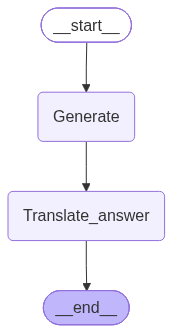

In [22]:
graph

In [23]:
graph.invoke(input={
    'question':'write a 500 words essay about himalayas ?'
})

{'question': 'write a 500 words essay about himalayas ?',
 'answer': "### The Majestic Himalayas: Nature’s Pinnacle\n\nThe Himalayas, often referred to as the “abode of snow,” is the highest mountain range in the world, extending across five countries: India, Nepal, Bhutan, China, and Pakistan. Spanning over 2,400 kilometers (1,500 miles), these magnificent mountains are not just a geographical marvel but also a critical ecological and cultural entity that sustains millions of lives. The Himalayas serve as a natural barrier, significantly influencing the climate of the Indian subcontinent, and are the source of many major rivers, including the Ganges, Indus, and Brahmaputra.\n\nThe grandeur of the Himalayas is epitomized by their towering peaks, among which Mount Everest, known as Sagarmatha in Nepali and Chomolungma in Tibetan, stands as the highest in the world at an astonishing height of 8,848 meters (29,029 feet). These heights, formed through the collision of the Indian and Eurasi